# Importing Libraries

In [92]:
import pandas as pd
import numpy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)
import re
import string
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from matplotlib import pyplot as plt

# Reading Dataset

In [93]:
sia = SentimentIntensityAnalyzer()
lemmatizer = WordNetLemmatizer()
tfidf = TfidfVectorizer(max_features = 30000, ngram_range=(1,2))

In [94]:
scores = sia.polarity_scores("You are absolutely disgusting and worthless")
print(scores)

{'neg': 0.632, 'neu': 0.368, 'pos': 0.0, 'compound': -0.7818}


In [95]:

data = pd.read_csv(r"C:\Users\milan\OneDrive\Desktop\CyberBullying detection-Part 1\cyberbullying_tweets.csv")
data

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying
...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity
47688,Turner did not withhold his disappointment. Tu...,ethnicity
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity


# Data Analysis

In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


### Checking Null Values

In [97]:
data.isnull().sum()

tweet_text            0
cyberbullying_type    0
dtype: int64

In [98]:
data['cyberbullying_type'].value_counts()

cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

# Data Preprocessing

### Renaming Columns

In [99]:
data = data.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'sentiment'})

### Encoding Columns

In [100]:
data["sentiment_encoded"] = data['sentiment'].map({"religion": 1, "age": 2, "ethnicity": 3, "gender": 4, "other_cyberbullying": 5,"not_cyberbullying": 6})

In [101]:
data.sample(10)

,text,sentiment,sentiment_encoded
6682,I'm so angry! That bread roll alone should be ...,not_cyberbullying,6
17055,Just post the flag of ISIS which says 1st vers...,religion,1
17195,"Children in Pakistan, journalists in Paris, sh...",religion,1
16367,"RT @sudixitca: Our Prophet Our Honor = Rape, B...",religion,1
12397,"Not sure yet how I feel about #Vicious, love t...",gender,4
1972,Taste of Sydney selfie with Colin from #mkr #m...,not_cyberbullying,6
15533,Are you for fucking real? @A5madAl I am not se...,gender,4
6044,Bout to go get fucked by this math exam idk sh...,not_cyberbullying,6
22543,"Read UNHRC report on India, you will know what...",religion,1
8964,Aftr reading all the Rape n Gay jokes on Chris...,gender,4


In [102]:
import nltk
nltk.download('stopwords', quiet = True)
custom_stopwords = {
    'rt', 'amp', 'get', 'got', 'make', 'like', 'say',
    'said', 'one', 'would', 'could', 'also', 'think',
    'know', 'go', 'going', 'use', 'time', 'mkr', 'al',
    'cal', 'im', 'dont', 'ur', 'u', 'funy', 'wil',
    'right', 'people', 'even', 'back', 'see', 'want',
    'need', 'still', 'way', 'good', 'really', 'much',
    'many', 'come', 'look', 'thing', 'take', 'give',
    'suport', 'schol', 'buly', 'se', 'amp', 'mkr',
    'get', 'go', 'one', 'would', 'make', 'say',
    'like', 'know', 'im', 'al', 'people', 'midle',
    'ur', 'rt', 'caled', 'first', 'anything', 
    'even', 'never', 'every', 'always', 'still',
    'back', 'last', 'much', 'many', 'us'
}
stop_words = set(stopwords.words('english')).union(custom_stopwords)

### Fucntion to Convert text to lowercase, remove (/r, /n characters), URLs, non-utf characters, Numbers, punctuations,stopwords

In [103]:

# ── FIX: Emoji → sentiment word map (preserves friendly intent) ──────────
EMOJI_MAP = {
    '❤️': ' love ', '😂': ' laugh ', '💀': ' laugh ',
    '😭': ' sad ',  '🥰': ' love ', '😡': ' angry ',
    '🤣': ' laugh ', '😊': ' happy ', '💔': ' heartbroken ',
    '😍': ' love ', '🙏': ' respect ', '👍': ' good ',
    '🔥': ' fire ', '💯': ' great ', '😘': ' love ',
    '😢': ' sad ', '🤦': ' facepalm ', '🥺': ' sad ',
    '😤': ' frustrated ', '🖕': ' offensive ',
}

def strip_all_entities(text):
    text = text.replace('\r', '').replace('\n', ' ').lower()
    text = re.sub(r"(?:\@|https?\://)\S+", "", text)

    # FIX: Convert emojis to sentiment words BEFORE stripping non-ASCII
    for emoji, word in EMOJI_MAP.items():
        text = text.replace(emoji, word)

    text = re.sub(r'[^\x00-\x7f]', r'', text)  # strip remaining non-ASCII
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub('[0-9]+', '', text)
    stopchars = string.punctuation
    table = str.maketrans('', '', stopchars)
    text = text.translate(table)
    text = [word for word in text.split() if word not in stop_words]
    text = [lemmatizer.lemmatize(word, pos='v') for word in text]
    text = ' '.join(text)
    return text


In [104]:
print(preprocess("He was running and eating while the dogs were barking loudly"))

run eat dog bark loudly


### Function to remove contractions


In [105]:
def decontract(text):
    text = re.sub(r"can\'t", "can not", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    return text

In [106]:
def preprocess(text):
    text = decontract(text)
    text = strip_all_entities(text)
    return text

In [107]:
data

,text,sentiment,sentiment_encoded
0,"In other words #katandandre, your food was cra...",not_cyberbullying,6
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,6
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,6
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,6
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,6
...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,3
47688,Turner did not withhold his disappointment. Tu...,ethnicity,3
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,3
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,3


In [108]:
data['cleaned_text'] = data['text'].apply(preprocess)
data.head()

,text,sentiment,sentiment_encoded,cleaned_text
0,"In other words #katandandre, your food was cra...",not_cyberbullying,6,word katandandre food crapilicious
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,6,aussietv white theblock imacelebrityau today s...
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,6,classy whore red velvet cupcakes
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,6,meh p thank head concern another angry dude tw...
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,6,isis account pretend kurdish account islam lie


In [109]:
data["cleaned_text"].duplicated().sum()

np.int64(3511)

In [110]:
data.drop_duplicates("cleaned_text", inplace=True)

In [111]:
data.sentiment.value_counts()

sentiment
religion               7942
age                    7855
ethnicity              7700
gender                 7529
not_cyberbullying      7503
other_cyberbullying    5652
Name: count, dtype: int64

### Extracting Text Length

In [112]:
text_len = []
for text in data.cleaned_text:
    tweet_len = len(text.split())
    text_len.append(tweet_len)

In [113]:
data['text_len'] = text_len

In [114]:
data

,text,sentiment,sentiment_encoded,cleaned_text,text_len
0,"In other words #katandandre, your food was cra...",not_cyberbullying,6,word katandandre food crapilicious,4
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,6,aussietv white theblock imacelebrityau today s...,10
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,6,classy whore red velvet cupcakes,5
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,6,meh p thank head concern another angry dude tw...,9
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,6,isis account pretend kurdish account islam lie,7
...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,3,black ppl expect depend yet free participate w...,19
47688,Turner did not withhold his disappointment. Tu...,ethnicity,3,turner withhold disappointment turner call cou...,28
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,3,swear god dumb nigger bitch bleach hair real f...,12
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,3,yea fuck youre nigger fuck unfollow fuck dumb ...,9


In [115]:
data['vader_neg'] = data['cleaned_text'].apply(lambda x: sia.polarity_scores(x)['neg'])
data['vader_neu'] = data['cleaned_text'].apply(lambda x: sia.polarity_scores(x)['neu'])
data['vader_pos'] = data['cleaned_text'].apply(lambda x: sia.polarity_scores(x)['pos'])
data['vader_compound'] = data['cleaned_text'].apply(lambda x: sia.polarity_scores(x)['compound'])


In [116]:
data[['cleaned_text', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']].head(10)

,cleaned_text,vader_neg,vader_neu,vader_pos,vader_compound
0,word katandandre food crapilicious,0.000,1.000,0.000,0.0000
1,aussietv white theblock imacelebrityau today s...,0.000,1.000,0.000,0.0000
2,classy whore red velvet cupcakes,0.422,0.294,0.284,-0.3400
3,meh p thank head concern another angry dude tw...,0.380,0.413,0.207,-0.2732
4,isis account pretend kurdish account islam lie,0.189,0.811,0.000,-0.1027
5,yes test god bad indifferent weird whatever pr...,0.417,0.298,0.286,-0.2960
6,itu sekolah ya bukan tempat bully ga jauh kaya...,0.262,0.738,0.000,-0.4939
7,karma hope bite kat butt nasty,0.343,0.381,0.276,-0.1779
8,everything mostly priest,0.000,1.000,0.000,0.0000
9,rebecca black drop school due bully,0.570,0.430,0.000,-0.6486


C:\Users\milan\AppData\Local\Temp\ipykernel_38684\2991988888.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='text_len', data=data[data['text_len']<10], palette='mako')


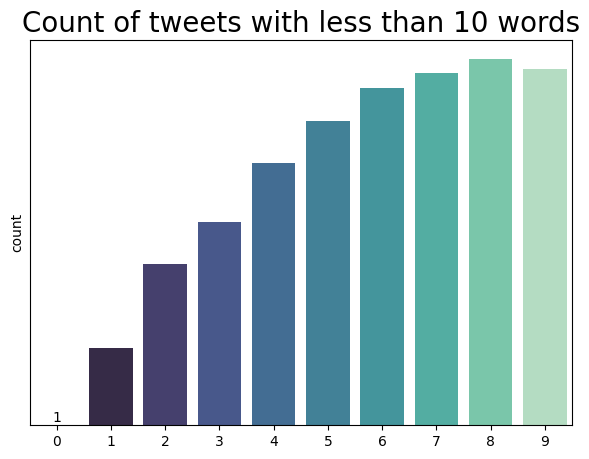

In [117]:
plt.figure(figsize=(7,5))
ax = sns.countplot(x='text_len', data=data[data['text_len']<10], palette='mako')
plt.title('Count of tweets with less than 10 words', fontsize=20)
plt.yticks([])
ax.bar_label(ax.containers[0])
plt.ylabel('count')
plt.xlabel('')
plt.show()

In [118]:
data.sort_values(by=['text_len'], ascending=False)
data

,text,sentiment,sentiment_encoded,cleaned_text,text_len,vader_neg,vader_neu,vader_pos,vader_compound
0,"In other words #katandandre, your food was cra...",not_cyberbullying,6,word katandandre food crapilicious,4,0.000,1.000,0.000,0.0000
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,6,aussietv white theblock imacelebrityau today s...,10,0.000,1.000,0.000,0.0000
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,6,classy whore red velvet cupcakes,5,0.422,0.294,0.284,-0.3400
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,6,meh p thank head concern another angry dude tw...,9,0.380,0.413,0.207,-0.2732
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,6,isis account pretend kurdish account islam lie,7,0.189,0.811,0.000,-0.1027
...,...,...,...,...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,3,black ppl expect depend yet free participate w...,19,0.178,0.414,0.408,0.8020
47688,Turner did not withhold his disappointment. Tu...,ethnicity,3,turner withhold disappointment turner call cou...,28,0.109,0.891,0.000,-0.5106
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,3,swear god dumb nigger bitch bleach hair real f...,12,0.665,0.248,0.087,-0.9325
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,3,yea fuck youre nigger fuck unfollow fuck dumb ...,9,0.819,0.181,0.000,-0.9590


### Removing Tweets which have less than 3 words and greater than 100 words

In [119]:
data = data[data['text_len'] > 3]
data = data[data['text_len'] < 100]

In [120]:
data

,text,sentiment,sentiment_encoded,cleaned_text,text_len,vader_neg,vader_neu,vader_pos,vader_compound
0,"In other words #katandandre, your food was cra...",not_cyberbullying,6,word katandandre food crapilicious,4,0.000,1.000,0.000,0.0000
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,6,aussietv white theblock imacelebrityau today s...,10,0.000,1.000,0.000,0.0000
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,6,classy whore red velvet cupcakes,5,0.422,0.294,0.284,-0.3400
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,6,meh p thank head concern another angry dude tw...,9,0.380,0.413,0.207,-0.2732
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,6,isis account pretend kurdish account islam lie,7,0.189,0.811,0.000,-0.1027
...,...,...,...,...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,3,black ppl expect depend yet free participate w...,19,0.178,0.414,0.408,0.8020
47688,Turner did not withhold his disappointment. Tu...,ethnicity,3,turner withhold disappointment turner call cou...,28,0.109,0.891,0.000,-0.5106
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,3,swear god dumb nigger bitch bleach hair real f...,12,0.665,0.248,0.087,-0.9325
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,3,yea fuck youre nigger fuck unfollow fuck dumb ...,9,0.819,0.181,0.000,-0.9590


### Building Wordcloud for Every Class

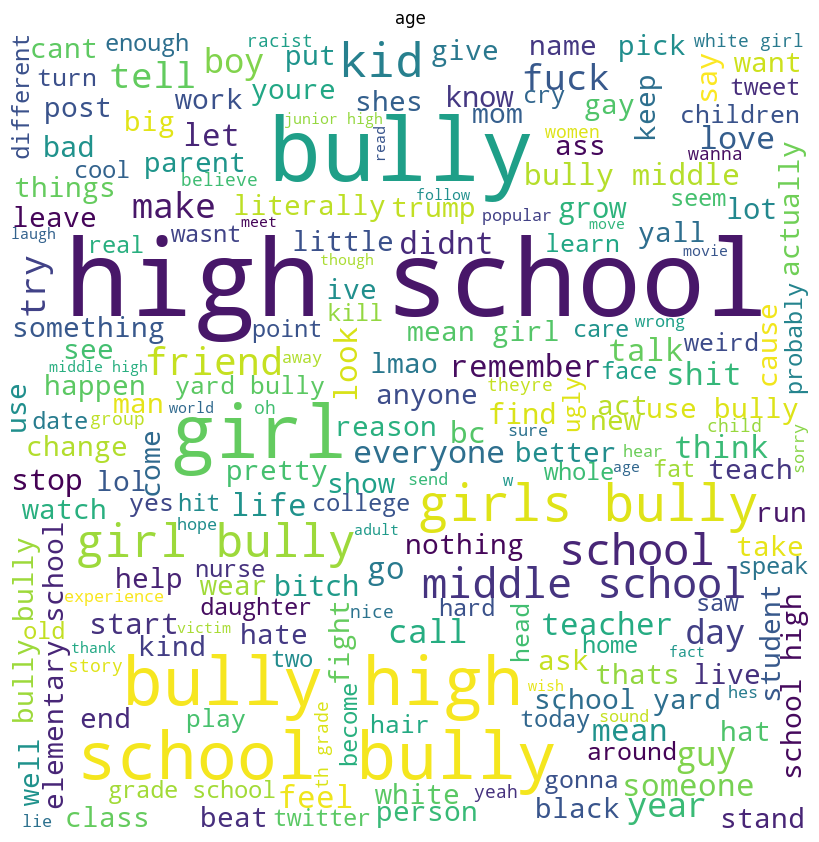

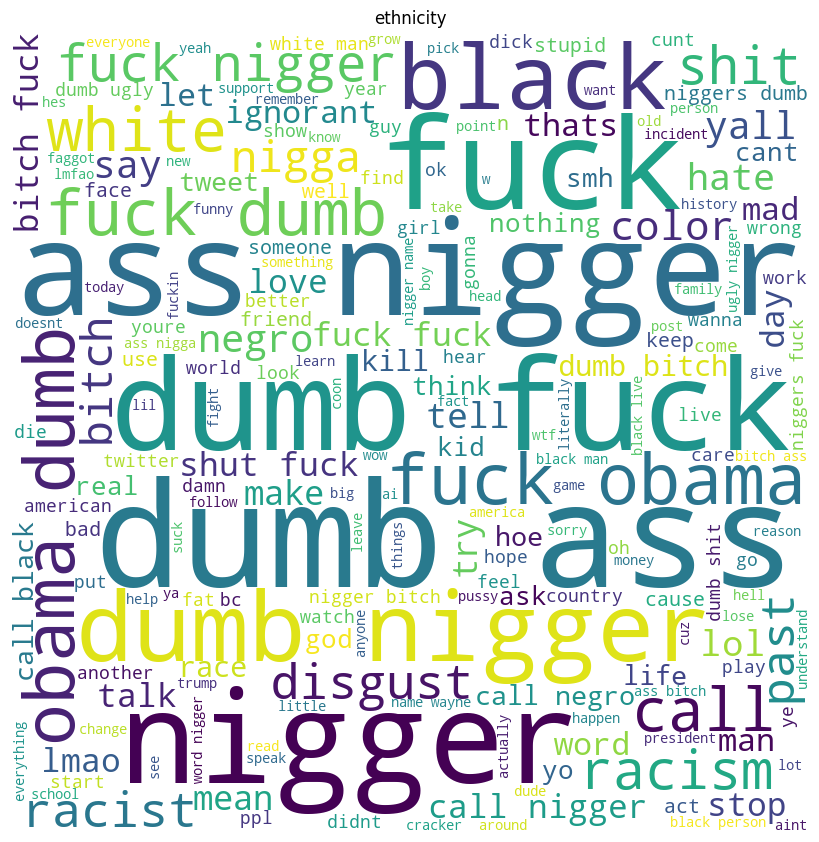

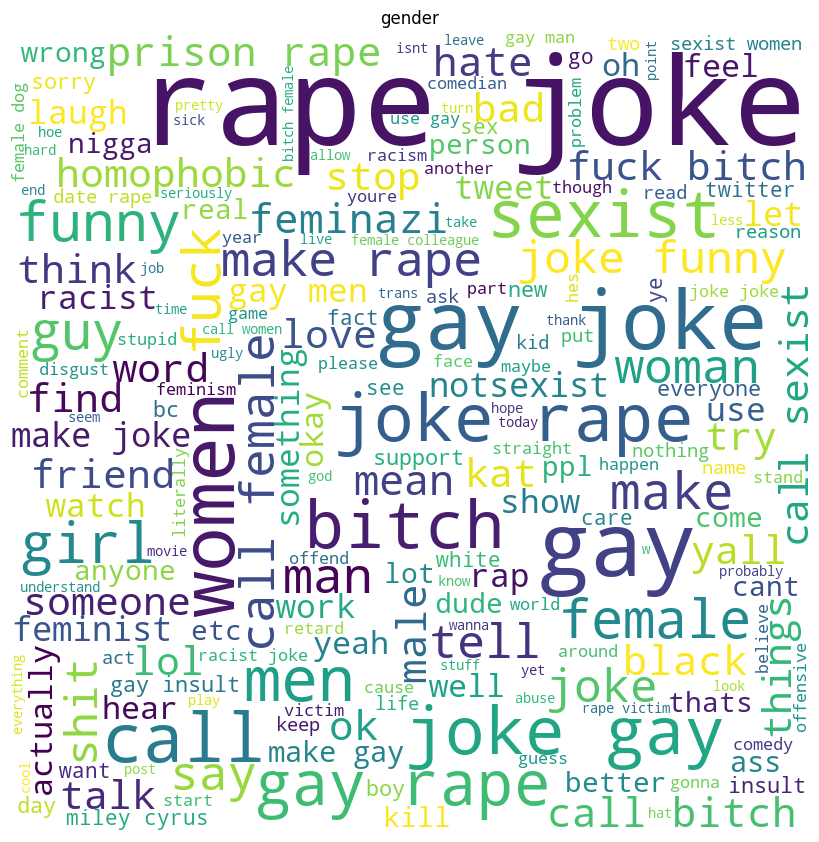

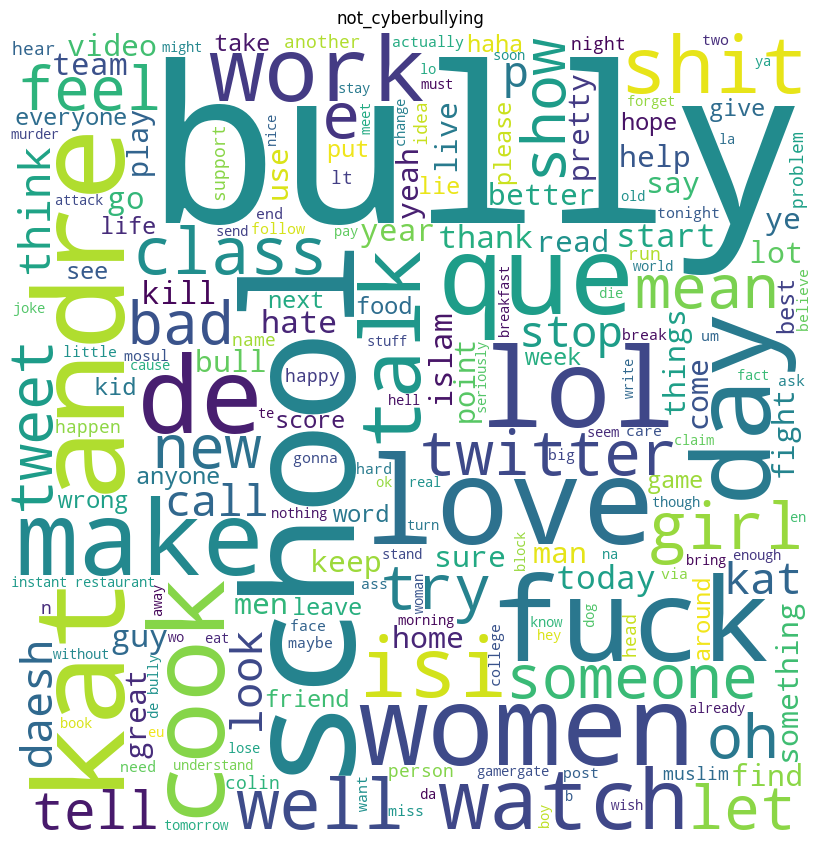

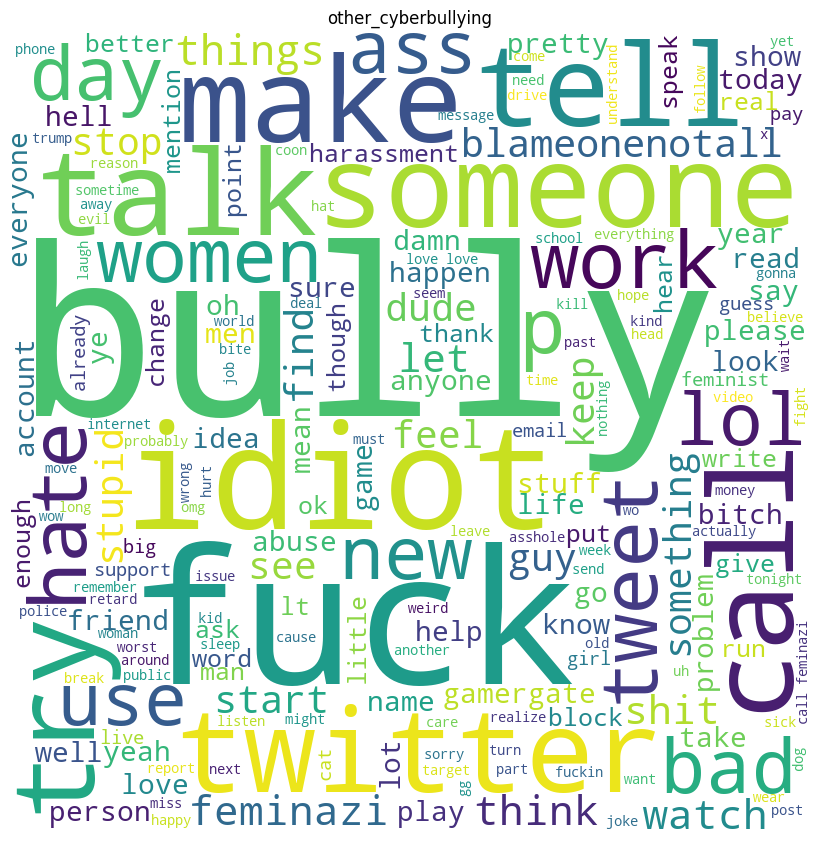

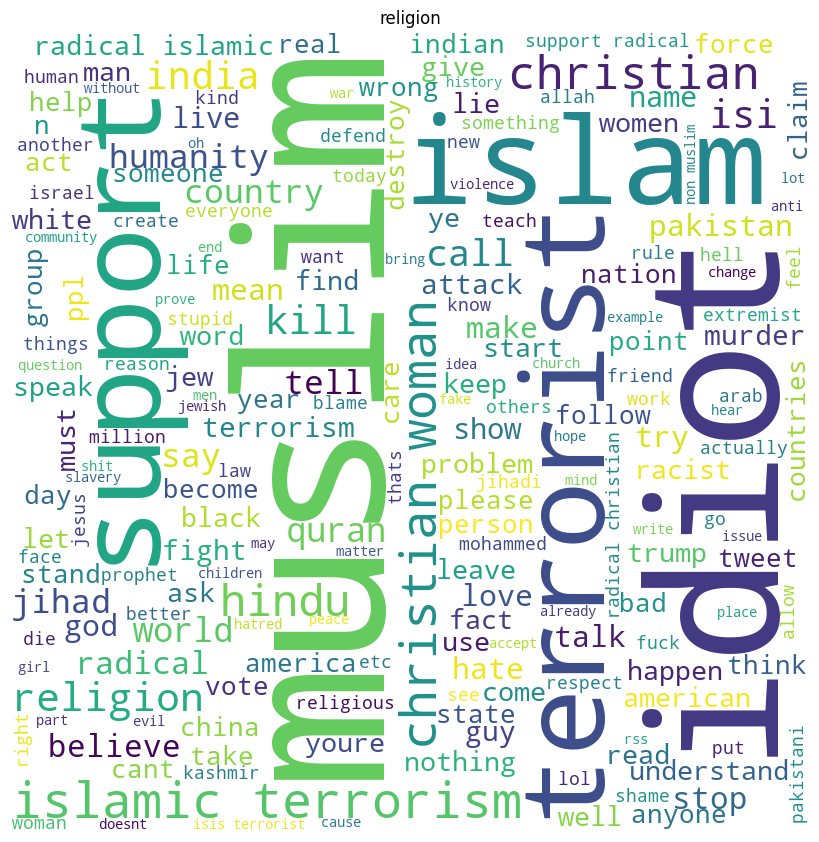

In [121]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sklearn.preprocessing import LabelEncoder

lenc = LabelEncoder()
data['sentiment_encoded'] = lenc.fit_transform(data.sentiment)

for c in range(len(lenc.classes_)):
    string = ""
    for i in data[data.sentiment_encoded == c].cleaned_text.values:
        string = string + " " + i.strip()

    #custom_mask = np.array(Image.open('../input/twitter-pic/twitter.png'))
    wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                min_font_size = 10).generate(string)

    # plot the WordCloud image
    plt.figure(figsize = (8, 8), facecolor = None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad = 0)
    plt.title(lenc.classes_[c])
    plt.show()
    del string

In [122]:
# ── FIX: Balance classes before training ─────────────────────────────────────
# The dataset is ~85% bullying content which biases the model heavily.
# We resample so every class contributes more equally during training.

from sklearn.utils import resample

min_count = data['sentiment'].value_counts().min()

balanced_dfs = []
for label in data['sentiment'].unique():
    cls_df = data[data['sentiment'] == label]
    # Oversample minority classes; cap majority at 2x minority size
    target = min(len(cls_df), min_count * 2)
    resampled = resample(
        cls_df,
        replace=len(cls_df) < target,
        n_samples=target,
        random_state=42
    )
    balanced_dfs.append(resampled)

data_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
print("Balanced class distribution:")
print(data_balanced['sentiment'].value_counts())


Balanced class distribution:
sentiment
religion               7843
age                    7783
ethnicity              7581
gender                 7083
not_cyberbullying      5787
other_cyberbullying    4306
Name: count, dtype: int64


In [123]:
# Use balanced dataset for TF-IDF fitting
X = tfidf.fit_transform(data_balanced['cleaned_text'])
print(X.shape)


(40383, 30000)


In [124]:
data['sentiment'].value_counts()

sentiment
religion               7843
age                    7783
ethnicity              7581
gender                 7083
not_cyberbullying      5787
other_cyberbullying    4306
Name: count, dtype: int64

In [125]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(data_balanced['sentiment'])
print(le.classes_)


['age' 'ethnicity' 'gender' 'not_cyberbullying' 'other_cyberbullying'
 'religion']


In [126]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)
print(X_train.shape)
print(X_test.shape)

(32306, 30000)
(8077, 30000)


In [127]:
# ── FIX: ComplementNB is designed for imbalanced text classification ─────
# It trains on the complement of each class, so it's far less biased
# toward the majority class compared to standard MultinomialNB.
from sklearn.naive_bayes import ComplementNB

model = ComplementNB(alpha=0.3)   # higher alpha = smoother, less overfit
model.fit(X_train, y_train)


ComplementNB(alpha=0.3)

In [128]:
y_pred = model.predict(X_test)
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8042590070570756


In [129]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names = le.classes_))

                     precision    recall  f1-score   support

                age       0.79      0.98      0.88      1557
          ethnicity       0.88      0.91      0.89      1516
             gender       0.86      0.86      0.86      1417
  not_cyberbullying       0.69      0.42      0.52      1157
other_cyberbullying       0.59      0.40      0.47       861
           religion       0.82      0.99      0.90      1569

           accuracy                           0.80      8077
          macro avg       0.77      0.76      0.75      8077
       weighted avg       0.79      0.80      0.79      8077



In [130]:
import pickle
print('pickle imported')

pickle imported


In [131]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('le.pkl', 'wb') as f:
    pickle.dump(le, f)

print('✅ model.pkl, tfidf.pkl, le.pkl saved.')

✅ model.pkl, tfidf.pkl, le.pkl saved.


In [132]:
import os
print(os.listdir())

['.ipynb_checkpoints', '.~lock.3140707_COA_.docx#', '.~lock.DMlabmanual.odt#', '.~lock.Formatted_Report.docx#', '01ListReadingCombinedAnsSheetRao (1).pdf', '01ListReadingCombinedAnsSheetRao.pdf', '075681_electric-shock-33018.mp3', '1. Application From Student.pdf', '1706782127Automatic Detection of Cyber Bullying (1).docx', '1706782127Automatic Detection of Cyber Bullying (2).docx', '1706782127Automatic Detection of Cyber Bullying (3).docx', '1706782127Automatic Detection of Cyber Bullying.docx', '2. NOC for Internship-2025-26 Mitesh.pdf', '2023-01-01-00_00_2023-01-01-23_59_Sentinel-2_L2A_True_color.jpg', '220220131120_CompletionCertificate.pdf', '240874.pdf', '3130006(PAS)(APY Material).pdf', '3130702.pdf', '3130702_Data Structure_LabManual_GECP (1).docx', '3130702_Data Structure_LabManual_GECP manish yadav345_33-67_replaced .pdf', '3130702_Data Structure_LabManual_GECP.docx', '3140705_OOP-I_Lab Manual (1).docx', '3140705_OOP-I_Lab Manual.docx', '3140705_OOP-I_Lab_Manual[1] 5 and 6.do

StreamLit:

In [133]:
import streamlit
print(streamlit.__version__)

1.44.1


In [134]:
with open('y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)

with open('y_pred.pkl', 'wb') as f:
    pickle.dump(y_pred, f)

In [135]:
import os
print('y_test.pkl' in os.listdir())
print('y_pred.pkl' in os.listdir())

True
True


In [136]:
data[['text', 'sentiment', 'cleaned_text']].to_csv('cyberbullying_cleaned.csv', index=False)

In [137]:
print(custom_stopwords)

{'said', 'back', 'need', 'still', 'come', 'first', 'look', 'midle', 'even', 'right', 'rt', 'see', 'time', 'say', 'amp', 'know', 'make', 'thing', 'last', 'could', 'every', 'people', 'also', 'want', 'think', 'cal', 'much', 'many', 'got', 'im', 'go', 'ur', 'funy', 'really', 'anything', 'us', 'never', 'al', 'wil', 'way', 'good', 'buly', 'would', 'get', 'like', 'give', 'use', 'suport', 'schol', 'se', 'take', 'u', 'always', 'dont', 'one', 'going', 'caled', 'mkr'}


In [138]:
import string
print(preprocess("Girls are so dumb and should stay in the kitchen"))
print(preprocess("Hello World"))

girls dumb stay kitchen
hello world


In [139]:
import pandas as pd
df = pd.read_csv('cyberbullying_cleaned.csv')
print(df[df['text'].str.contains('Girls are so dumb', case=False, na=False)]['cleaned_text'].values)

[]


In [140]:
print(df['cleaned_text'].head(10).values)

['word katandandre food crapilicious'
 'aussietv white theblock imacelebrityau today sunrise studio neighbour wonderlandten etc'
 'classy whore red velvet cupcakes'
 'meh p thank head concern another angry dude twitter'
 'isis account pretend kurdish account islam lie'
 'yes test god bad indifferent weird whatever prove gods existence'
 'itu sekolah ya bukan tempat bully ga jauh kaya neraka'
 'karma hope bite kat butt nasty' 'rebecca black drop school due bully'
 'turkish state kill children years news googleeviricitopluluukrteyidee']


## ✅ Fixes Applied

| Fix | What changed | Why |
|-----|-------------|-----|
| **Class balancing** | Resampled data to ~2× min-class size | 85% bullying bias caused model to always predict bullying |
| **ComplementNB** | Replaced `MultinomialNB` with `ComplementNB(alpha=0.3)` | Designed for imbalanced text; far less majority-class bias |
| **Emoji map** | Emojis converted to sentiment words before ASCII strip | ❤️😂 were silently removed, losing friendly-intent signals |

> After retraining, re-export `model.pkl`, `tfidf.pkl`, `le.pkl`, `y_test.pkl`, `y_pred.pkl`.